---

<h1><center>ENGIN178 Final Project<br><br> Group 14 </center></h1>

---
This project is designed to take blended body delta wing aircraft positional state given in yaw angle, pitch angle, as well as the absolute and relative degree of elevon and map that to aerodynamic force and moment coefficients to be used in a controller.

0. Load the data from the master sheet
1. Scramble the ordered data from the mastersheet into a new shuffled csv file
2. Split the data into training, validation, and testing datasets
3. Normalize the data using Scikit-Learn 'Standard-Scaler()' method
4. Organize and fit our data into input sequences and output values
5. Train and test the following models
    + 5.1 Multi-Linear Regression 
    + 5.2 Gradient Boosted Trees 
    + 5.3 MLP Neural-Network 

6. Compare the models
7. Choose the best model

In [ ]:
#%pip install --upgrade pip
#%pip install --extra-index-url https://download.pytorch.org/whl/cpu torch
#%pip install tensorboard

Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cpu
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 45.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 73.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [tensorboard] [tensorboard]
Note: you may need to restart the kernel to use updated packages.


In [1]:
%load_ext tensorboard
%tensorboard --logdir runs

In [32]:
#importing dependencies 
import os
import pickle
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime
from IPython.display import clear_output, display
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torch.utils.tensorboard import SummaryWriter 
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

np.set_printoptions(precision=4)

def predict_model(model, x):
    model.eval()
    x_tensor = torch.tensor(np.asarray(x), dtype=torch.float32)
    with torch.no_grad():
        yhat = model(x_tensor).detach().cpu().numpy()
    return yhat

def predict_any(model, x):
    if isinstance(model, nn.Module):
        return predict_model(model, x)
    return model.predict(x)


## 0.  Importing the aero parameter 'Master Sheet'

Straightforward import of the ordered master sheet into our notebook using a Pandas data frame, we also remove a vestigal column describing the data source

In [3]:
# loads the data and removes the 'source_file' output column
#rawDat = pd.read_csv('aero_autosweep.csv').drop('source_file', axis=1)
rawDat = pd.read_csv('aero_autosweep.csv')
testDat = pd.read_csv('aero_nonposed_cleaned.csv')


## 1. Shuffle the aero parameter 'Master Sheet'

The raw data from the master sheet is organized in the angle of attack sweeps due to how data formatting is done in VSPAero. This means that if we were to split this csv using the sequential sorting of training, validation, and test data we would be missing entire sweeps for the training data. 

+ To remedy this the rows of the csv need to be randomly shuffled to ensure an even distribution of the different cfd sweeps. Using pandas [`df.sample()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sample.html) method using a specific random state (to ensure consistency).

In [4]:
shuffledDat = rawDat.sample(frac=1, random_state = 67).reset_index(drop=True).to_csv('shuffledAeroMaster.csv', index=False)
shuffledTest = testDat.sample(frac=1, random_state = 67).reset_index(drop=True).to_csv('shuffledTestSweep.csv', index=False)

In [4]:
# if the shuffle has alreday been done just run this 
shuffledDat = pd.read_csv('shuffledAeroMaster.csv')
shuffledTest = pd.read_csv('shuffledTestSweep.csv')

## 2. Splitting the shuffled data

We want to split up our shuffled data into respective train, validate, and test data sets. A good way to do this is by defining our ratios that we want to split the data, then sequentially slicing off the specified ratios into their respective sets.

**This is crucially done before normalizing the data to prevent data leakage in our training.**

+ In this specific case we chose a 70% train, 10% validate, and 20% test ratio.



In [5]:
# create the function that will split our data up into train, validate, and test lists. pt indicates percent train, pv 
# indicates percent validate... please use float not percent!!!

def splitData(d,pt,pv):

    assert(pt>=0)
    assert(pv>=0)

    N = d.shape[0]

    trainEnd = int(N*pt)
    valEnd = trainEnd + int(N*pv)

    dataTrain = d.copy().iloc[:trainEnd]
    dataValidate = d.copy().iloc[trainEnd:valEnd]
    dataTest = d.copy().iloc[valEnd:]

    
    return dataTrain, dataValidate, dataTest

In [6]:
# run the function to actually split the data
dataTrain, dataValidate, dataTestRaw = splitData(shuffledDat,0.70,0.10)

# split the off axis data in half for a 2/3 ratio
halfData = shuffledTest.iloc[:len(shuffledTest) // 2]

# combine both test sets
dataTest = pd.concat([dataTestRaw, halfData], axis=0)


## 3. Normalizing each dataset

This dataset doesn't have a large feature range, but it is still required that we normalize the data to insure there is no feature domination during our training. We can do this very easily using [`StandardScaler()`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) and normalize our inputs and outputs.

In [7]:
# normalize and scale the data using StandardScaler() method from scikit learn
from sklearn.preprocessing import StandardScaler

xScaler = StandardScaler()
yScaler = StandardScaler()

## 4. Organizing and fitting out inputs and outputs 

We need to define what our inputs and outputs are:
+ X = Attitude $\alpha$ & $\beta$, combined elevon pitch, and elevon $\Delta$. 
+ Y = $C_L, C_d, C_y, C_l, C_m, C_n$

Once this is done we must scale all of our data according to the scaled variables we defined in the previous section (`xScaled` & `yScaled`). 
+ We use [`fit_transform()`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler.fit_transform) on our training data to calculate its stats then apply the scale, for all other data we simply use [`transform()`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler.transform) to prevent data leakage.

In [8]:
# creates our input/output training set
xTrain = dataTrain[["alpha_deg","beta_deg","deltaS_deg","deltaD_deg"]]
yTrain = dataTrain[["CL","CD","CY","Cl","Cm","Cn"]]

# creates our input/output validate set
xValidate = dataValidate[["alpha_deg","beta_deg","deltaS_deg","deltaD_deg"]]
yValidate = dataValidate[["CL","CD","CY","Cl","Cm","Cn"]]

# creates our input/output test set
xTest = dataTest[["alpha_deg","beta_deg","deltaS_deg","deltaD_deg"]]
yTest = dataTest[["CL","CD","CY","Cl","Cm","Cn"]]

# scales all of our inputs
xTrainScaled = xScaler.fit_transform(xTrain)
xTestScaled = xScaler.transform(xTest)
xValidateScaled = xScaler.transform(xValidate)

# scales all of our outputs
yTrainScaled = yScaler.fit_transform(yTrain)
yTestScaled = yScaler.transform(yTest)
yValidateScaled = yScaler.transform(yValidate)

## 5. Training and tests our models

We will be training and testing the following models
+ 5.1 Multi-Linear Regression 
+ 5.2 Gradient Boosted Trees 
+ 5.3 MLP Neural-Network 

## 5.1 Building multi-linear regression

This will be our simplest model to act as a baseline to compare all of our other models to. We know that some of our parameters should exhibit a **linear relationship** with attitude, specifically:
+ $C_L$ (Coefficient of Lift)
+ $C_m$ (Coefficient of Moment)

These parameters should yield a **very strong** linear model. In future training sessions we can compare the relative performance for our linear parameters. 

However not all of these parameters are known to show a linear relationship with attitude, specifically:
+ $C_l$ (Coefficient of roll)
+ $C_n$ (Coefficient of yaw/normal)
+ $C_Y$ (Coefficient of aerodynamic side-force)
+ $C_d$ (Coefficient of drag)

### 5.1.1 Initlizing and traning the linear regression model

Creating and training a LR model using Scikit-Learn is very simple, we simply create the LR model then train it on scaled data. We can then use the model with the validation set to evaluate its Mean Absolute Error.

In [9]:
from sklearn.linear_model import LinearRegression

# create our sklearn regression model
modelLr = LinearRegression()

# train the model, it gets scaled inputs and will learn to map them to the unscaled targets
modelLr.fit(xTrainScaled, yTrain)

LinearRegression()

### 5.1.2 Extract MAE

We'll extract and display the individual MAE of each of the parameters to get a metric of performance.

In [10]:
# predict with the validation set
validatePred = modelLr.predict(xValidateScaled)

# model evaluation using MAE 
individualMaes = mean_absolute_error(yValidate, validatePred, multioutput='raw_values')

parameters = ["CL", "CD", "CY", "Cl", "Cm", "Cn"]
print("Multi-Linear Regression Validation MAE by Parameter:")
for param, mae in zip(parameters, individualMaes):
    print(f"{param}: {mae:.5f}")

Multi-Linear Regression Validation MAE by Parameter:
CL: 0.00599
CD: 0.01739
CY: 0.00311
Cl: 0.00444
Cm: 0.00942
Cn: 0.00224


## 5.2 Building gradient boosted trees 

As the previous model has shown many of these parameters are not depicted well with a linear regression. Using gradient boosted trees we can model non-linear parameters for a relativly low resource cost as is works very well with tabular data and is much simpler to run than a neural network. 

### 5.2.1 Regularization 
Because gradient boosted trees utilizes decision trees, we can't use standard ridge or lasso regularization to prevent the model from overfitting. The weights applied simply do not work with this model, however we can use `min_samples_leaf` and `max_depth` to control the fitting. 

In [19]:
from scipy.stats import uniform, randint

# parameter directory 
paramDistributions = {
    'estimator__n_estimators': randint(100, 300), # limits number of trees 
    'estimator__learning_rate': uniform(0.01, 0.1), # throttles the changes made to subsequent trees      
    'estimator__max_depth': randint(3, 8), # limits depth of trees                
    'estimator__min_samples_leaf': randint(1, 5) # limits number of tree branches
}

### 5.2.2 Hyperparamter tuning with RandomizedSearchCV

Randomized search is generally the standard tuner for a relativley inconsequential dataset like this, while there are more advanced options randomized search offers a good balance between performance and efficiency. 

In [20]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import RandomizedSearchCV

# initilize models
baseGbr = GradientBoostingRegressor(random_state=42)
multiGbt = MultiOutputRegressor(baseGbr)


# set up RandomizedSearchCV
randomSearch = RandomizedSearchCV(
    estimator=multiGbt,
    param_distributions=paramDistributions,
    n_iter=30,
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=2, 
    random_state=42,
    n_jobs=1  
)

# prints each interation of hyperparameter tuning
print("Starting Hyperparameter Tuning. This may take a few minutes...")
randomSearch.fit(xTrainScaled, yTrain)

# finishes and saves model
bestGbtModel = randomSearch.best_estimator_
print("\n--- Tuning Complete ---")



Starting Hyperparameter Tuning. This may take a few minutes...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV] END estimator__learning_rate=0.047454011884736254, estimator__max_depth=7, estimator__min_samples_leaf=3, estimator__n_estimators=206; total time=   2.2s
[CV] END estimator__learning_rate=0.047454011884736254, estimator__max_depth=7, estimator__min_samples_leaf=3, estimator__n_estimators=206; total time=   2.0s
[CV] END estimator__learning_rate=0.047454011884736254, estimator__max_depth=7, estimator__min_samples_leaf=3, estimator__n_estimators=206; total time=   2.3s
[CV] END estimator__learning_rate=0.047454011884736254, estimator__max_depth=7, estimator__min_samples_leaf=3, estimator__n_estimators=206; total time=   2.1s
[CV] END estimator__learning_rate=0.047454011884736254, estimator__max_depth=7, estimator__min_samples_leaf=3, estimator__n_estimators=206; total time=   2.0s
[CV] END estimator__learning_rate=0.08796910002727693, estimator__max_depth=7, e

### 5.2.3 Extract MAE

We'll extract and display the individual MAE of each of the parameters to get a metric of performance.

In [21]:
gbtPredictions = bestGbtModel.predict(xValidateScaled)
gbtMaeIndividual = mean_absolute_error(yValidate, gbtPredictions, multioutput='raw_values')

parameters = ["CL", "CD", "CY", "Cl", "Cm", "Cn"]

print("Gradient Boosted Trees Validation MAE by Parameter:")
for param, mae in zip(parameters, gbtMaeIndividual):
    print(f"{param:2s} MAE: {mae:.6f}")
    

Gradient Boosted Trees Validation MAE by Parameter:
CL MAE: 0.000608
CD MAE: 0.000076
CY MAE: 0.000143
Cl MAE: 0.000273
Cm MAE: 0.000569
Cn MAE: 0.000062


The gradient boosted trees algorithm shows significant improvements on the linear model, particularly in the non-linear varibles mentioned earlier.

### 5.2.4 Evaluation of parameter dependence

Because random trees natively calculate 'feature dependence' we can easily extract this data to anaylze what flight configurations influence which parameter the most, verifying our model with aerodynamic intuition. 

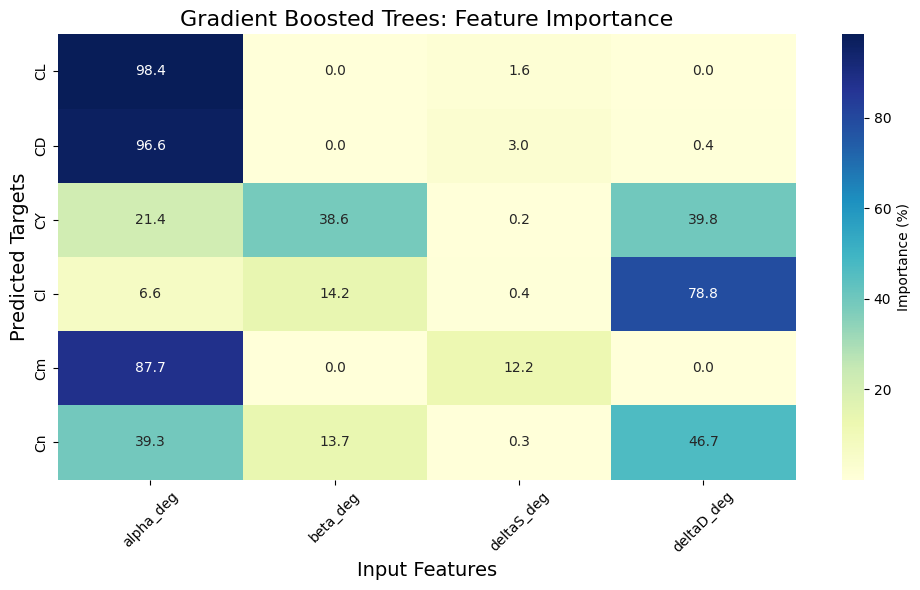

In [22]:
import seaborn as sns

# get feature and target names
featureNames = ["alpha_deg", "beta_deg", "deltaS_deg", "deltaD_deg"]
targetNames = ["CL", "CD", "CY", "Cl", "Cm", "Cn"]

# extracts the features from the mor 
importanceMatrix = []
for estimator in bestGbtModel.estimators_:
    importanceMatrix.append(estimator.feature_importances_ * 100) 

# seaborn likes dataframes, so we convert our importance matrix to a pandas dataframe
importanceDf = pd.DataFrame(importanceMatrix, columns=featureNames, index=targetNames)

# plot 
plt.figure(figsize=(10, 6))
sns.heatmap(importanceDf, annot=True, cmap="YlGnBu", fmt=".1f", cbar_kws={'label': 'Importance (%)'})

plt.title('Gradient Boosted Trees: Feature Importance', fontsize=16)
plt.xlabel('Input Features', fontsize=14)
plt.ylabel('Predicted Targets', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5.3 Building a MLP neural network

A neural network is by far the most advanced option we have for modeling. Unlike the previous two models which rely on independent regression, a neural network takes in all parameters and considers them for its learning scheme, allowing us to explore other methods for evaluation that we were not able to use before. 

### 5.3.1 Intitilizing the MLP neural network

Using PyTorch we can get a neural network up and running, we just use a funnel architecture, taking the 4 inputs and splitting them into 64 'neurons', which is then fed through a hyperbolic tangent activation function and is 'funneled' down into the 6 outputs. 

We chose a Tanh activation function instead of a Sigmoid or ReLu for two reasons:
+ Sigmoid is not **zero-centered**, our data by nature contains negative values, sigmoid is good for probablistic classification, but not our use-case.
+ ReLu is a 'sharp' activation function, meaning that approximating our smooth data can be worsened by the jagged spikes created by such a black and white function.

In [12]:
torch.manual_seed(2434)

D = xTrainScaled.shape[1]

mlpModel = nn.Sequential( 
        nn.Linear(D, 64),
        nn.Tanh(),
        nn.Linear(64, 32),
        nn.Tanh(),
        nn.Linear(32, 16),
        nn.Tanh(),
        nn.Linear(16, 6)
        )

for layer in mlpModel:
    if isinstance(layer, nn.Linear):
        nn.init.xavier_uniform_(layer.weight)
        nn.init.zeros_(layer.bias)

### 5.3.2 Converting our data into torch tensors

The nature of these neural networks require our data to be converted into tensors. We convert the data then shove it into a dataloader that creates batches of 32. 

In [13]:
xTrainScaledTensor = torch.tensor(xTrainScaled, dtype=torch.float32)
yTrainScaledTensor = torch.tensor(yTrainScaled, dtype=torch.float32)

xValidateScaledTensor = torch.tensor(xValidateScaled, dtype=torch.float32)
yValidateScaledTensor = torch.tensor(yValidateScaled, dtype=torch.float32)

trainLoader = DataLoader(
    TensorDataset(xTrainScaledTensor, yTrainScaledTensor),
    batch_size=32,
    shuffle=True
)

### 5.3.3 Training the MLP

The training consists of three steps:

1. Setup Phase
    + We setup the training algorithm by first creating our optimizer `optim.Adam()` and our loss function `nn.MSELoss()`. These will tweak the internal weights of the MLP to minimize error. We also define our epochs, in this case 500 epochs.
2. Training Phase
    + The trainer makes a forward pass with `pred = modelSrnn(xb)`. The model looks at the sequence of control inputs (xb) and makes its prediction. It then takes this prediction and puts it through our MSE loss function.
    + The trainer then back-propigates to calculate the gradients, changing the internal weights to minimize loss from the MSE function. The optimizer then "learns" from these changes and the model gets better.
3. Evaluation Phase
    + PyTorch model processes data as tensors with `Tensor.cpu()`
The training concludes by unscaling the values back into the aero parameters.

In [14]:
random.seed(2434)
torch.manual_seed(2434)

current_time = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

# Append the timestamp to the folder name
log_path = f"runs/mlp_aero_run_{current_time}"
writer = SummaryWriter(log_dir=log_path)

lossFunctionMLP = nn.MSELoss()
optimizerMLP = optim.Adam(mlpModel.parameters(), lr=0.001)

historyMLP = {
    "epoch": [],
    "trainMAE": [],
    "validateMAE": []
}

numEpochs = 500

for epoch in range(numEpochs):
    mlpModel.train()

    for xb, yb in trainLoader:
        optimizerMLP.zero_grad()

        yhatTrain = mlpModel(xb)   # shape: [batch_size, 6]
        loss = lossFunctionMLP(yhatTrain, yb)

        loss.backward()
        optimizerMLP.step()

    mlpModel.eval()

    with torch.no_grad():
        trainPredScaled = mlpModel(xTrainScaledTensor).cpu().numpy()
        validatePredScaled = mlpModel(xValidateScaledTensor).cpu().numpy()

    # convert scaled predictions back to actual aero coefficient values
    trainPred = yScaler.inverse_transform(trainPredScaled)
    validatePred = yScaler.inverse_transform(validatePredScaled)

    yTrainActual = yScaler.inverse_transform(yTrainScaled)
    yValidateActual = yScaler.inverse_transform(yValidateScaled)

    trainMAE = mean_absolute_error(yTrainActual, trainPred)
    validateMAE = mean_absolute_error(yValidateActual, validatePred)

    historyMLP["epoch"].append(epoch)
    historyMLP["trainMAE"].append(trainMAE)
    historyMLP["validateMAE"].append(validateMAE)

    if epoch % 50 == 0:
        print(f"Epoch {epoch:4d} | Train MAE: {trainMAE:.6f} | Validate MAE: {validateMAE:.6f}")

Epoch    0 | Train MAE: 0.021838 | Validate MAE: 0.021442
Epoch   50 | Train MAE: 0.002192 | Validate MAE: 0.002124
Epoch  100 | Train MAE: 0.001311 | Validate MAE: 0.001311
Epoch  150 | Train MAE: 0.001607 | Validate MAE: 0.001607
Epoch  200 | Train MAE: 0.000966 | Validate MAE: 0.000961
Epoch  250 | Train MAE: 0.000841 | Validate MAE: 0.000852
Epoch  300 | Train MAE: 0.000809 | Validate MAE: 0.000793
Epoch  350 | Train MAE: 0.001297 | Validate MAE: 0.001268
Epoch  400 | Train MAE: 0.000944 | Validate MAE: 0.000954
Epoch  450 | Train MAE: 0.000698 | Validate MAE: 0.000703


### 5.3.4 Extracting the MAE for the MLP

We'll extract and display the individual MAE of each of the parameters to get a metric of performance.

In [15]:
coefNames = ["CL", "CD", "CY", "Cl", "Cm", "Cn"]

validateMAEEach = mean_absolute_error(
    yValidateActual,
    validatePred,
    multioutput="raw_values"
)

print("MLP Validation MAE by Parameter:")
for name, mae in zip(coefNames, validateMAEEach):
    print(f"{name} MAE: {mae:.6f}")

MLP Validation MAE by Parameter:
CL MAE: 0.003602
CD MAE: 0.000309
CY MAE: 0.000058
Cl MAE: 0.000112
Cm MAE: 0.001303
Cn MAE: 0.000019


### 5.3.5 Creating a weighted MSE loss function

While for the other two models our abilities to create weighted loss function were limited by the fact that each coefficient was regressed independent of eachother. With a MLP that consideres *all* information at once, making a weighted MSE viable. 

In [16]:
class WeightedMSELoss(nn.Module):
    def __init__(self, weights):
        super(WeightedMSELoss, self).__init__()
        # turns weights into a tensor
        self.weights = torch.tensor(weights, dtype=torch.float32)

    def forward(self, predictions, targets):
        # calculate raw squared error for each parameter
        squared_errors = (predictions - targets) ** 2
        
        # multiply errors by their respective parameter weight
        weighted_errors = squared_errors * self.weights.to(predictions.device)
        
        # return the mean of all weighted errors
        return torch.mean(weighted_errors)

### 5.3.6 Retraining the MLP with the weighted loss function and scheduler

With our new loss function created, we can swap out the default unweighted loss function for the MLP with our new weighted one and see if any considerable improvements have been made. We also included a scheduler to prevent large sweeps of learning, instead tapering off learning rate as we go through epochs and evaluate our loss functions, resulting in a smooth convergence.

In [27]:
random.seed(2434)
torch.manual_seed(2434)

# initilize tensorboard
current_time = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
log_path = f"runs/mlp_aero_run_{current_time}"
writer = SummaryWriter(log_dir=log_path)

weights = [1.0, 1.0, 1.0, 5.0, 5.0, 5.0]
lossFunctionMLP = WeightedMSELoss(weights=weights)
optimizerMLP = torch.optim.Adam(mlpModel.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizerMLP, gamma=0.99)

parameters = ["CL", "CD", "CY", "Cl", "Cm", "Cn"]
numEpochs = 500

# native plots
historyMLP = {
    "epoch": [],
    "trainMAE_raw": [], 
    "validateMAE_raw": []
}

# training
for epoch in range(numEpochs):
    mlpModel.train()
    for xb, yb in trainLoader:
        optimizerMLP.zero_grad()
        yhatTrain = mlpModel(xb)   
        loss = lossFunctionMLP(yhatTrain, yb)
        loss.backward()
        optimizerMLP.step()
        
    scheduler.step()

    # evaluation
    mlpModel.eval()
    with torch.no_grad():
        trainPredScaled = mlpModel(xTrainScaledTensor).cpu().numpy()
        validatePredScaled = mlpModel(xValidateScaledTensor).cpu().numpy()

    trainPred = yScaler.inverse_transform(trainPredScaled)
    validatePred = yScaler.inverse_transform(validatePredScaled)
    yTrainActual = yScaler.inverse_transform(yTrainScaled)
    yValidateActual = yScaler.inverse_transform(yValidateScaled)

    trainMAE_raw = mean_absolute_error(yTrainActual, trainPred, multioutput='raw_values')
    validateMAE_raw = mean_absolute_error(yValidateActual, validatePred, multioutput='raw_values')

    
    # dictionary for the matplotlib plot
    historyMLP["epoch"].append(epoch)
    historyMLP["trainMAE_raw"].append(trainMAE_raw)
    historyMLP["validateMAE_raw"].append(validateMAE_raw)

    # send to tensorboard
    for i, param in enumerate(parameters):
        writer.add_scalars(f'Convergence_MAE/{param}', {
            'Train': trainMAE_raw[i],
            'Validation': validateMAE_raw[i]
        }, epoch)

    writer.add_scalar('Learning_Rate', scheduler.get_last_lr()[0], epoch)

writer.close()
print(f"Training Complete. TensorBoard saved to {log_path}")

Training Complete. TensorBoard saved to runs/mlp_aero_run_20260502-194911


### 5.3.7 Extracting MAE for weighted loss function

We'll extract and display the individual MAE of each of the parameters to get a metric of performance.

In [28]:
coefNames = ["CL", "CD", "CY", "Cl", "Cm", "Cn"]

validateMAEEach = mean_absolute_error(
    yValidateActual,
    validatePred,
    multioutput="raw_values"
)

print("Weighted MLP Validation MAE by Parameter:")
for name, mae in zip(coefNames, validateMAEEach):
    print(f"{name}: {mae:.6f}")

Weighted MLP Validation MAE by Parameter:
CL: 0.001693
CD: 0.000098
CY: 0.000031
Cl: 0.000042
Cm: 0.000381
Cn: 0.000006


## 6. Compare each model

Now that every model has been trained we can finally compare the performance of each. While we do already have our **MAE** metrics (which are useful for comparing against eachother) it is not helpful for determining how well the model is working. We will still use MAE but for evaluation we will be using the following for the respective data set.

+ Multi-output linear regression: $R^2$ & **NMAE**
+ Gradient Boosted Trees: $R^2$ & **NRMSE**
+ Weighted MLP: $R^2$ & **NRMSE**

## 6.1 Evaluating multi-output linear regression

With our model trained we can now evaluate its performance and plot its performance vs the actual data. In the previous section we calculated each parameters MAE, this metric is not entirely helpful as it doesn't account for the scale and variance of each specific output. 

To remedy this we employ an $R^2$ score and NMAE to evaluate the model accuracy, and get an idea of by how far off our predicted values are.

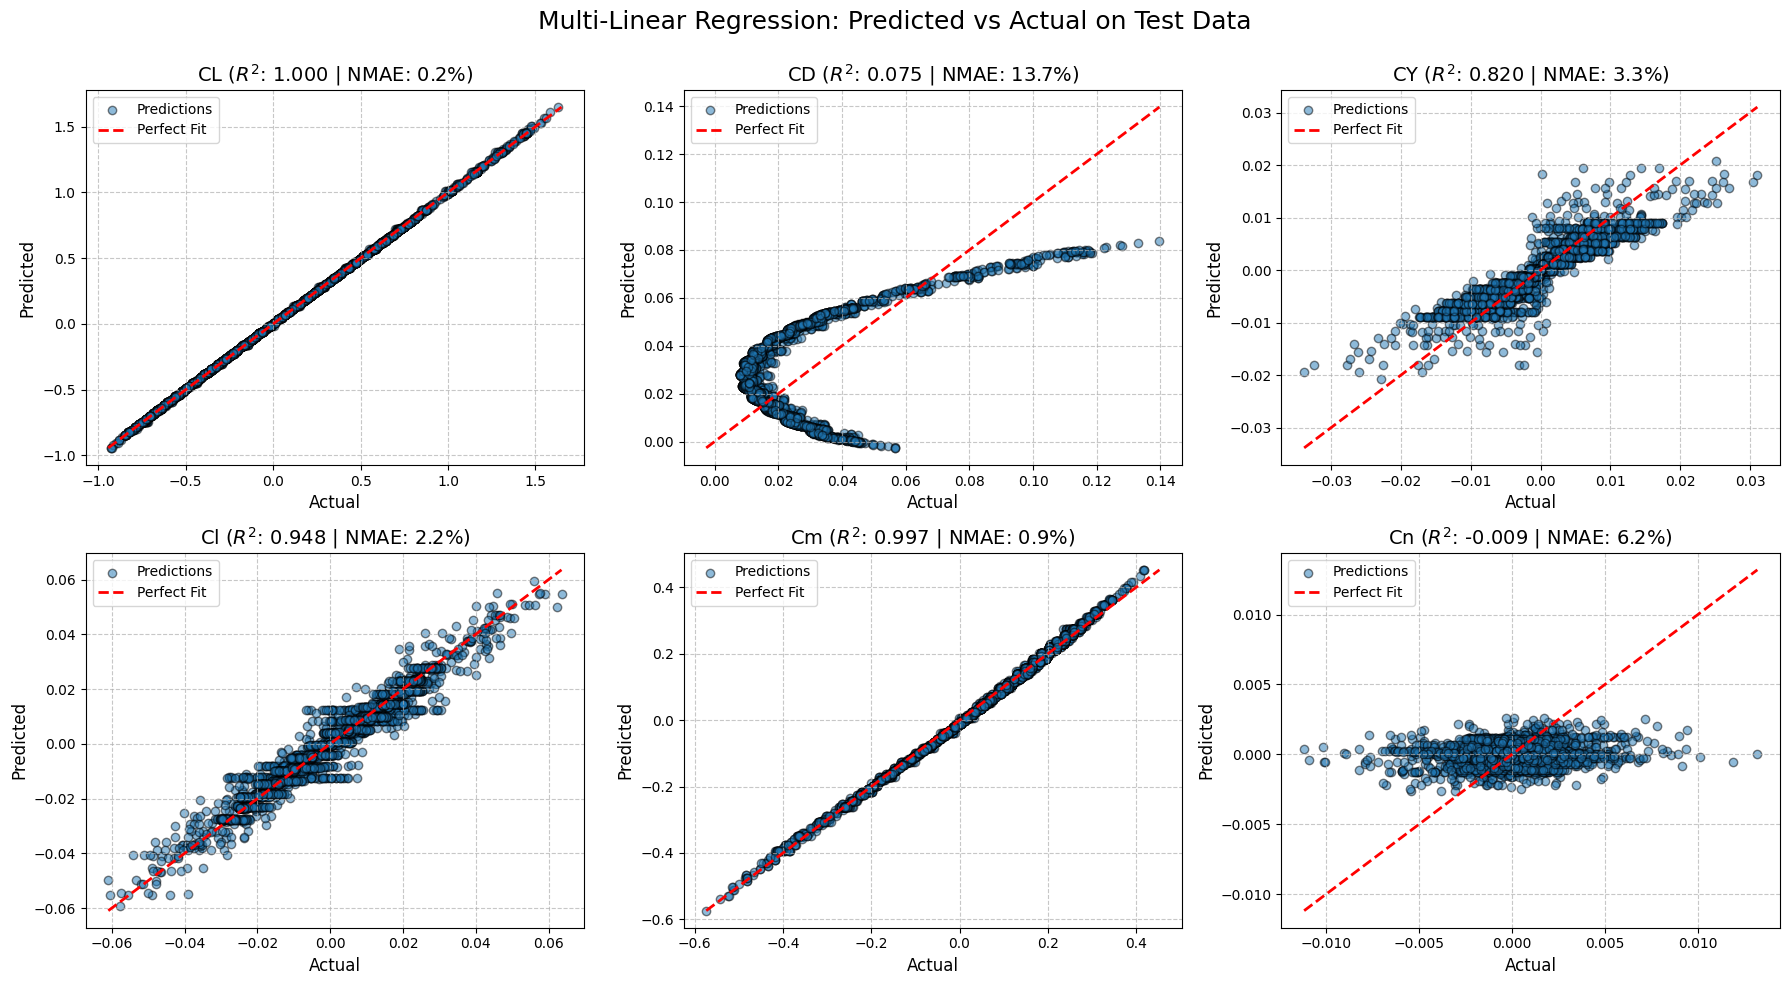

In [23]:
# extracts the test features then scales adequately 
xTest = dataTest[["alpha_deg", "beta_deg", "deltaS_deg", "deltaD_deg"]]
yTest = dataTest[["CL", "CD", "CY", "Cl", "Cm", "Cn"]]

xTestScaled = xScaler.transform(xTest)

# predict using the trained model
testPred = modelLr.predict(xTestScaled)

# calculate standard MAE and R^2 for all parameters
testMaes = mean_absolute_error(yTest, testPred, multioutput='raw_values')
testR2 = r2_score(yTest, testPred, multioutput='raw_values')

parameters = ["CL", "CD", "CY", "Cl", "Cm", "Cn"]

# plot generation
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Multi-Linear Regression: Predicted vs Actual on Test Data', fontsize=18)

axes = axes.flatten()

for i, target in enumerate(parameters):
    ax = axes[i]
    actual = yTest[target].values
    predicted = testPred[:, i]
    
    # calculate NMAE (normalized by the range of actual values)
    rangeVal = actual.max() - actual.min()
    nmae = (testMaes[i] / rangeVal) * 100 if rangeVal != 0 else 0
    
    # scatter plots
    ax.scatter(actual, predicted, alpha=0.5, edgecolor='k', label='Predictions')
    
    # creates and "ideal" line
    minVal = min(actual.min(), predicted.min())
    maxVal = max(actual.max(), predicted.max())
    ax.plot([minVal, maxVal], [minVal, maxVal], 'r--', lw=2, label='Perfect Fit')
    
    # titles and stuff
    ax.set_title(f"{target} ($R^2$: {testR2[i]:.3f} | NMAE: {nmae:.1f}%)", fontsize=14)
    ax.set_xlabel('Actual', fontsize=12)
    ax.set_ylabel('Predicted', fontsize=12)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

As the plot above shows, some of the parameters are much better suited towards linear regression than others.

+ $C_L$ & $C_m$ both exhibit a **perfectly linear** fit with very low NMAE scores, we can use this performance to gauge future model performance.
+ All of the other models however show some significant deviation from the perfect fit, in the $C_D$ plot we can see the parabolic relationship between attitude and drag (drag polar) very clearly on this graph. The other parameters have some odd relationships that do not fit to a linear regression very well.


## 6.2 Evaluating gradient boosted trees performance


### 6.2.1 Gradient boosted trees convergence per parameter 


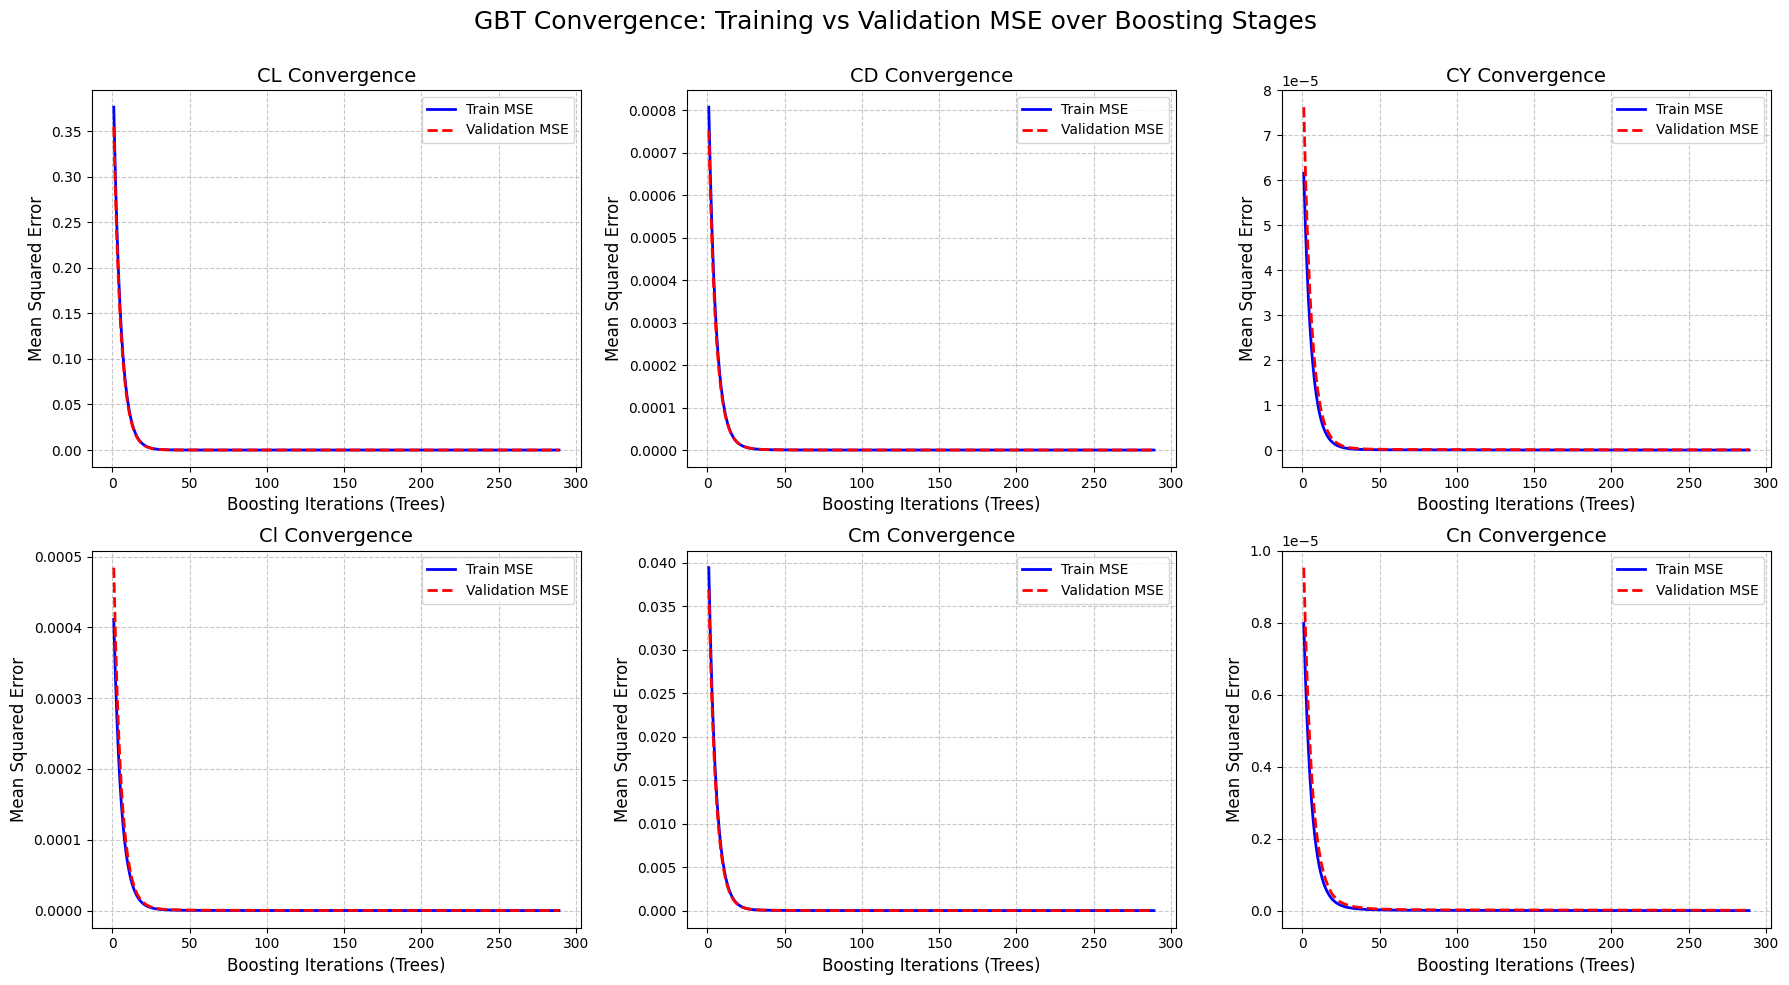

In [24]:
# convert to numpy arrays so we can slice them easily
yTrain_array = np.array(yTrain)
yValidate_array = np.array(yValidate)

parameters = ["CL", "CD", "CY", "Cl", "Cm", "Cn"]

# extract the GBT models
estimators = bestGbtModel.estimators_

# plot grid
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('GBT Convergence: Training vs Validation MSE over Boosting Stages', fontsize=18)

axes = axes.flatten()

# loop through each parameter and its corresponding trained model
for i, (param, estimator) in enumerate(zip(parameters, estimators)):
    ax = axes[i]
    
    # extract the actual values for this specific coefficient
    yTrain_single = yTrain_array[:, i]
    yVal_single = yValidate_array[:, i]
    
    # .staged_predict() returns an iterator yielding predictions at each stage (tree)
    train_errors = [mean_squared_error(yTrain_single, y_pred) 
                    for y_pred in estimator.staged_predict(xTrainScaled)]
    
    val_errors = [mean_squared_error(yVal_single, y_pred) 
                  for y_pred in estimator.staged_predict(xValidateScaled)]
    
    # x axis is the number of trees
    stages = np.arange(1, len(train_errors) + 1)
    
    # plot curves
    ax.plot(stages, train_errors, label='Train MSE', color='blue', linewidth=2)
    ax.plot(stages, val_errors, label='Validation MSE', color='red', linestyle='--', linewidth=2)
    
    ax.set_title(f"{param} Convergence", fontsize=14)
    ax.set_xlabel('Boosting Iterations (Trees)', fontsize=12)
    ax.set_ylabel('Mean Squared Error', fontsize=12)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

### 6.1.2 Gradient boosted trees performance per parameter

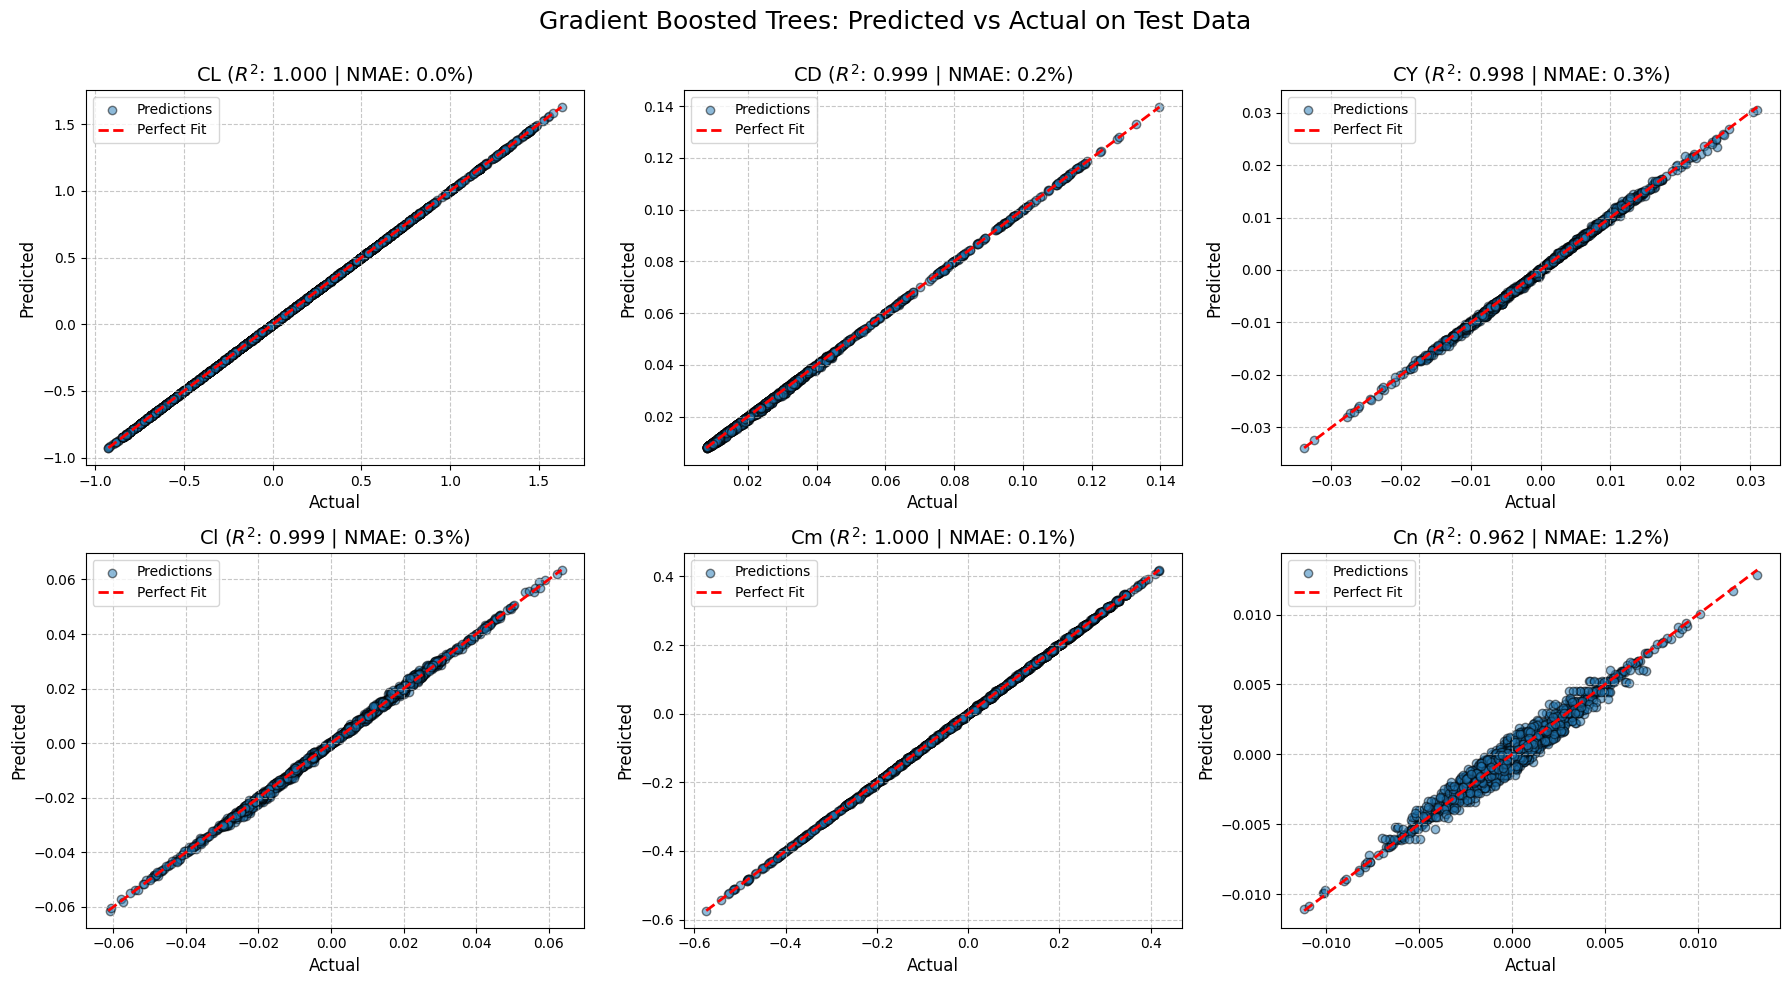

In [25]:
bestGbtModel = randomSearch.best_estimator_

# extracts the test features then scales adequately 
xTest = dataTest[["alpha_deg", "beta_deg", "deltaS_deg", "deltaD_deg"]]
yTest = dataTest[["CL", "CD", "CY", "Cl", "Cm", "Cn"]]

xTestScaled = xScaler.transform(xTest)

# predict using the trained model
testPred = bestGbtModel.predict(xTestScaled)

# calculate standard MAE and R^2 for all parameters
testMaes = mean_absolute_error(yTest, testPred, multioutput='raw_values')
testR2 = r2_score(yTest, testPred, multioutput='raw_values')

parameters = ["CL", "CD", "CY", "Cl", "Cm", "Cn"]

# plot generation
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Gradient Boosted Trees: Predicted vs Actual on Test Data', fontsize=18)

axes = axes.flatten()

for i, target in enumerate(parameters):
    ax = axes[i]
    actual = yTest[target].values
    predicted = testPred[:, i]
    
    # calculate NMAE (normalized by the range of actual values)
    rangeVal = actual.max() - actual.min()
    nmae = (testMaes[i] / rangeVal) * 100 if rangeVal != 0 else 0
    
    # scatter plots
    ax.scatter(actual, predicted, alpha=0.5, edgecolor='k', label='Predictions')
    
    # creates and "ideal" line
    minVal = min(actual.min(), predicted.min())
    maxVal = max(actual.max(), predicted.max())
    ax.plot([minVal, maxVal], [minVal, maxVal], 'r--', lw=2, label='Perfect Fit')
    
    # titles and stuff
    ax.set_title(f"{target} ($R^2$: {testR2[i]:.3f} | NMAE: {nmae:.1f}%)", fontsize=14)
    ax.set_xlabel('Actual', fontsize=12)
    ax.set_ylabel('Predicted', fontsize=12)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

The plot above shows **significant** improvement towards the overall performance of the model, specifically the $C_D$, $C_l$, $C_Y$ and $C_n$ outputs, (the non linear terms that we outlined). Most of the parameters exhibit a very high $R^2$ score and low **NMAE** values. However there is still some outlying parameters where the model could be improved in, specifically $C_n$. 

## 6.3 Evaluating weighted MLP performance

### 6.3.1 MLP convergence per parameter

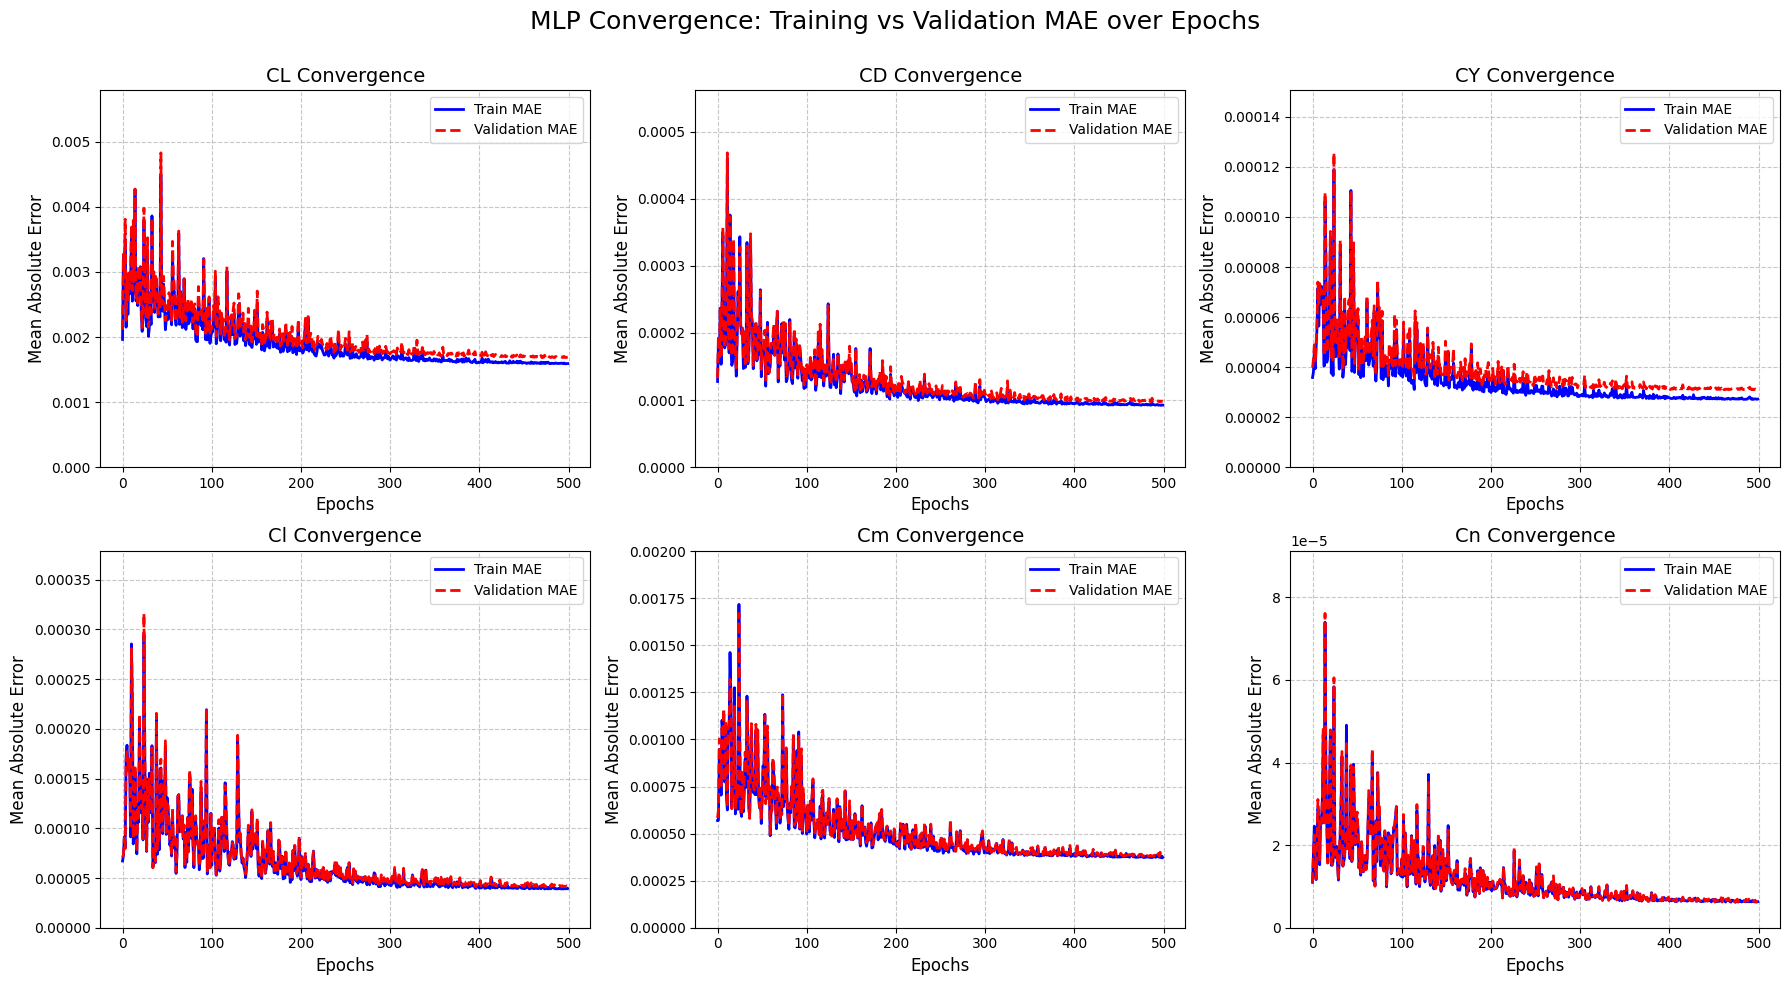

In [29]:
parameters = ["CL", "CD", "CY", "Cl", "Cm", "Cn"]

# convert the history lists into numpy arrays for easy column slicing
train_maes = np.array(historyMLP["trainMAE_raw"])
val_maes = np.array(historyMLP["validateMAE_raw"])
epochs = historyMLP["epoch"]

# plot grid
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('MLP Convergence: Training vs Validation MAE over Epochs', fontsize=18)

axes = axes.flatten()

for i, param in enumerate(parameters):
    ax = axes[i]
    
    # extract the error history
    train_history_single = train_maes[:, i]
    val_history_single = val_maes[:, i]
    
    # plot the 'curve'
    ax.plot(epochs, train_history_single, label='Train MAE', color='blue', linewidth=2)
    ax.plot(epochs, val_history_single, label='Validation MAE', color='red', linestyle='--', linewidth=2)
    ax.set_ylim(bottom=0, top=max(val_history_single[10:]) * 1.2)

    ax.set_title(f"{param} Convergence", fontsize=14)
    ax.set_xlabel('Epochs', fontsize=12)
    ax.set_ylabel('Mean Absolute Error', fontsize=12)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

### 6.3.2 Weighted MLP performance per parameter

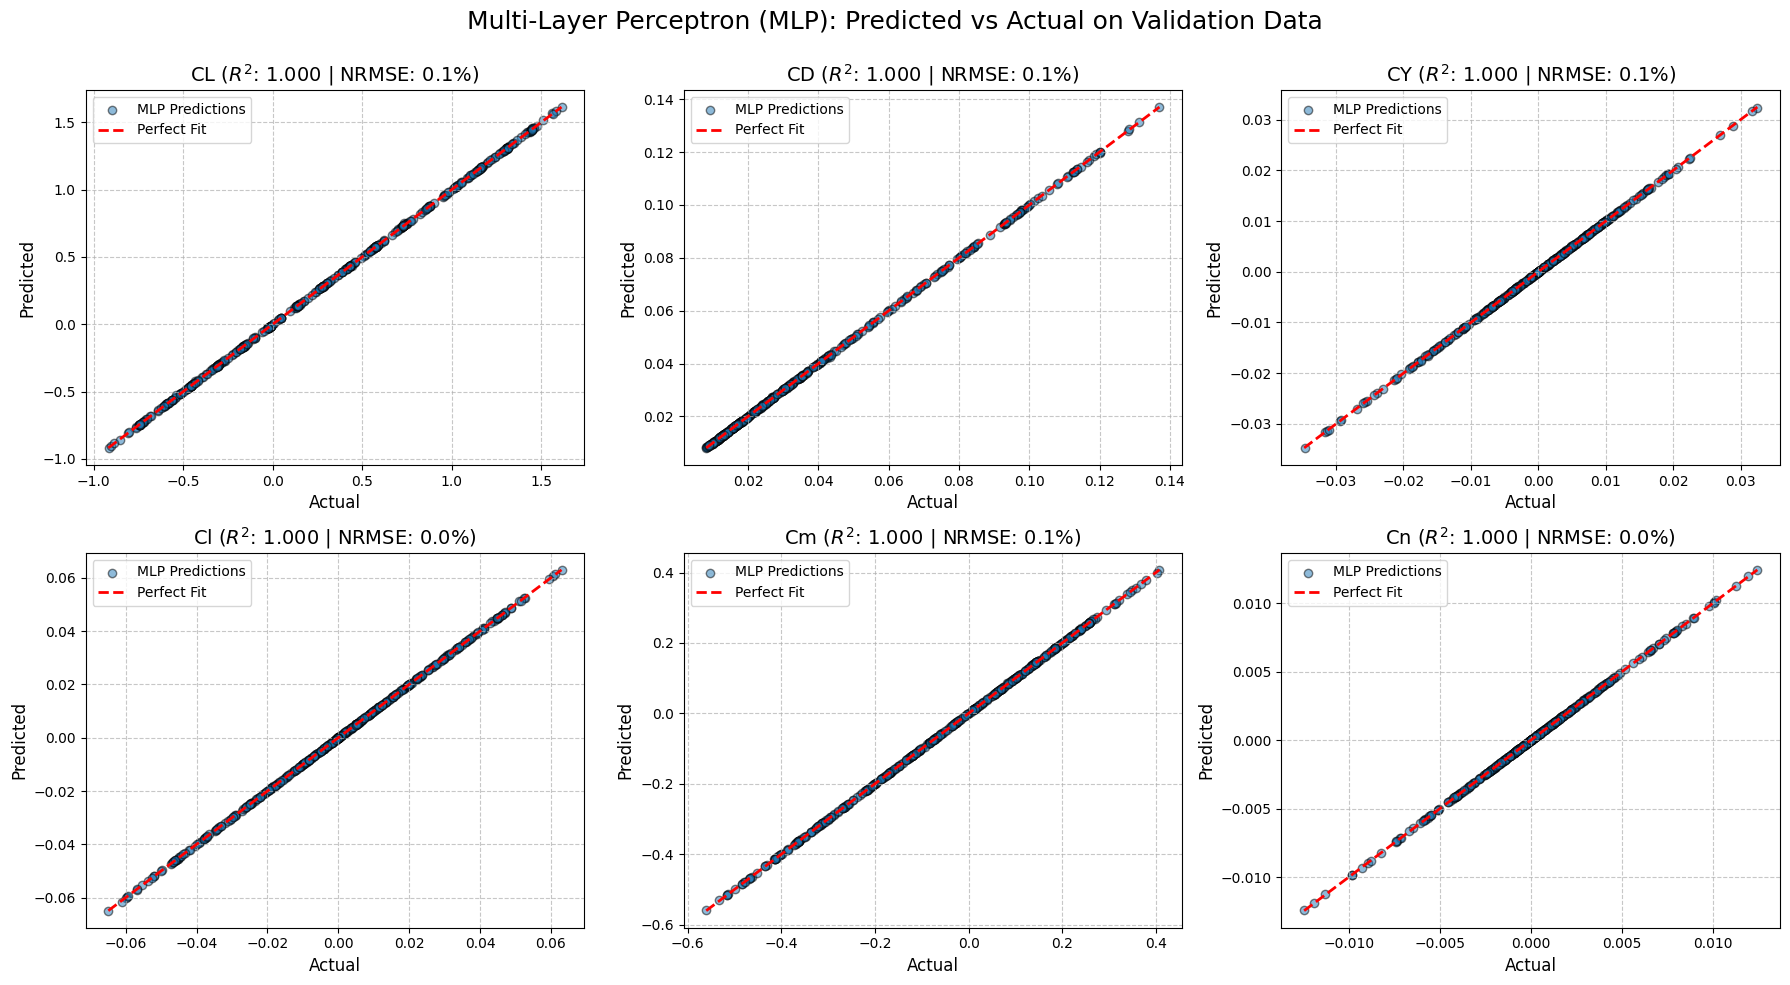

In [30]:
# calculate raw MSE, then take the square root to get RMSE for all parameters
mlpValMse = mean_squared_error(yValidateActual, validatePred, multioutput='raw_values')
mlpValRmse = np.sqrt(mlpValMse)

# calculate R-squared for all parameters
mlpValR2 = r2_score(yValidateActual, validatePred, multioutput='raw_values')

parameters = ["CL", "CD", "CY", "Cl", "Cm", "Cn"]

# plot grid
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Multi-Layer Perceptron (MLP): Predicted vs Actual on Validation Data', fontsize=18)

axes = axes.flatten()

for i, target in enumerate(parameters):
    ax = axes[i]
    
    # extract actual and predicted values for this specific parameter
    actual = yValidateActual[:, i]
    predicted = validatePred[:, i]
    
    # calculate NRMSE
    range_val = actual.max() - actual.min()
    nrmse = (mlpValRmse[i] / range_val) * 100 if range_val != 0 else 0
    
    # actual vs predicted scatter plot
    ax.scatter(actual, predicted, alpha=0.5, edgecolor='k', label='MLP Predictions')
    
    # ideal line
    min_val = min(actual.min(), predicted.min())
    max_val = max(actual.max(), predicted.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Fit')
    
    # add r-squared and NRMSE percentage to the title
    ax.set_title(f"{target} ($R^2$: {mlpValR2[i]:.3f} | NRMSE: {nrmse:.1f}%)", fontsize=14)
    ax.set_xlabel('Actual', fontsize=12)
    ax.set_ylabel('Predicted', fontsize=12)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

The model has reached its final form and has yielded excellent performance amongst all of the parameters. 

## 7. The best model is... MLP 

In [35]:
print("Calculating staged predictions for export... (This may take a moment)")

yTrain_array = np.array(yTrain)
yValidate_array = np.array(yValidate)
parameters = ["CL", "CD", "CY", "Cl", "Cm", "Cn"]
estimators = bestGbtModel.estimators_

all_train_errors = []
all_val_errors = []

for i, (param, estimator) in enumerate(zip(parameters, estimators)):
    yTrain_single = yTrain_array[:, i]
    yVal_single = yValidate_array[:, i]
    
    # Calculate all errors for this parameter
    train_errors = [mean_squared_error(yTrain_single, y_pred) 
                    for y_pred in estimator.staged_predict(xTrainScaled)]
    val_errors = [mean_squared_error(yVal_single, y_pred) 
                  for y_pred in estimator.staged_predict(xValidateScaled)]
    
    all_train_errors.append(train_errors)
    all_val_errors.append(val_errors)

# Package it all into a dictionary
gbt_export_data = {
    "train_errors": all_train_errors,
    "val_errors": all_val_errors,
    "stages": np.arange(1, len(all_train_errors[0]) + 1)
}

# Save it to a file
with open('gbt_history.pkl', 'wb') as file:
    pickle.dump(gbt_export_data, file)

print("GBT errors successfully saved to gbt_history.pkl!")

# Save the dictionary to a file named 'history.pkl'
with open('history.pkl', 'wb') as file:
    pickle.dump(historyMLP, file)

print("Training history successfully saved to history.pkl!")

Calculating staged predictions for export... (This may take a moment)
GBT errors successfully saved to gbt_history.pkl!
Training history successfully saved to history.pkl!
